# 06 — Clean Natural Experiments: Same Cultivar, Different Earth

These are the only currently honest terroir comparisons in the dataset:
same cultivar, different environment, measured metabolite values.
Genetic effects are controlled. Any difference is environmental.

| Experiment | RSUs | Contrast | Key metabolite |
|-----------|------|----------|----------------|
| Golden Delicious apple | RSU-13 vs RSU-14 | 600m vs 1050m altitude, Shanxi China | Malic acid (2×) |
| Sigoise olive oil | RSU-15 vs RSU-16 | Algerian highlands vs Saharan margin | Polyphenols (1.6×) |

**Source:** Zhao et al. 2021 *Foods* 10(12):2950 (apple); Guerfel et al. 2022 *Food Sci Nutr* (olive)

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from rsu_loader import load_all_rsus, parse_numeric_ranges

EXPERIMENTS = {
    'apple': {
        'food': 'Golden Delicious apple',
        'rsus': ['RSU-13', 'RSU-14'],
        'cultivar': 'Golden Delicious',
        'contrast': 'altitude',
        'source': 'Zhao et al. 2021 Foods 10(12):2950',
    },
    'olive': {
        'food': 'Sigoise olive',
        'rsus': ['RSU-15', 'RSU-16'],
        'cultivar': 'Sigoise',
        'contrast': 'water stress',
        'source': 'Guerfel et al. 2022 Food Sci Nutr PMC9179137',
    },
}

In [2]:
rsus = load_all_rsus()
ranges = parse_numeric_ranges(rsus)

env_map = {r.region_id: {
    'name': r.name,
    'geology': r.geology.parent_material,
    'soil_pH': r.geology.soil_pH,
    'temp_mean': r.climate.temperature_mean,
    'precip_mean': r.climate.precipitation_mean,
    'lat': r.coordinates.lat,
    'altitude_m': getattr(r.coordinates, 'altitude_m', None),
} for r in rsus}

# Collect all natural experiment data
exp_records = []
for exp_name, exp in EXPERIMENTS.items():
    for rsu_id in exp['rsus']:
        food_data = ranges.get(rsu_id, {}).get(exp['food'], {})
        for dim, (lo, hi) in food_data.items():
            exp_records.append({
                'experiment': exp_name,
                'food': exp['food'],
                'cultivar': exp['cultivar'],
                'contrast': exp['contrast'],
                'region_id': rsu_id,
                'dim': dim,
                'short_dim': dim.split('.')[-1],
                'value': (lo + hi) / 2,
                'lo': lo,
                'hi': hi,
                **env_map.get(rsu_id, {}),
            })

df = pd.DataFrame(exp_records)

print("Data loaded per experiment:")
for exp_name in EXPERIMENTS:
    sub = df[df['experiment'] == exp_name]
    dims = sub['dim'].unique().tolist()
    rsus_found = sub['region_id'].unique().tolist()
    print(f"  {exp_name}: {rsus_found}, dims: {[d.split('.')[-1] for d in dims]}")

Data loaded per experiment:
  apple: ['RSU-13', 'RSU-14'], dims: ['fructose_concentration', 'ascorbic_acid', 'malic_acid']
  olive: ['RSU-15', 'RSU-16'], dims: ['oleic_acid', 'linoleic_acid', 'polyphenol_content', 'tocopherol_content']


## Experiment 1: Apple — Altitude Gradient

**RSU-13** (Shanxi Lowlands, Yuncheng, ~600m) vs **RSU-14** (Shanxi Highlands, Linfen, ~1050m)

Same cultivar: *Golden Delicious*. Both from the same Shanxi Province study.
Environmental contrast: 450m altitude difference, cooler temperatures, similar precipitation.

**Expected mechanism:** Higher altitude = lower temperatures, higher UV, increased organic acid accumulation.
Malic acid is the primary apple organic acid and is temperature-sensitive during fruit maturation.

In [3]:
apple_df = df[df['experiment'] == 'apple'].copy()

print("Apple — Golden Delicious across altitude gradient:")
pivot = apple_df.pivot(index='dim', columns='region_id', values='value')

rsu13_col = 'RSU-13' if 'RSU-13' in pivot.columns else None
rsu14_col = 'RSU-14' if 'RSU-14' in pivot.columns else None

if rsu13_col and rsu14_col:
    pivot['delta'] = pivot[rsu14_col] - pivot[rsu13_col]
    pivot['ratio'] = (pivot[rsu14_col] / pivot[rsu13_col]).round(2)
    print(pivot.round(4).to_string())
else:
    print(pivot.round(4).to_string())
    print(f"\nMissing RSU columns — found: {list(pivot.columns)}")
    print("Check that RSU-13 and RSU-14 JSON files are present and loaded.")

print("\nEnvironmental context:")
for rsu_id in EXPERIMENTS['apple']['rsus']:
    e = env_map.get(rsu_id, {})
    print(f"  {rsu_id} {e.get('name','?')}: altitude={e.get('altitude_m','?')}m, "
          f"temp={e.get('temp_mean','?')}°C, precip={e.get('precip_mean','?')}mm, "
          f"geology={e.get('geology','?')}, pH={e.get('soil_pH','?')}")

Apple — Golden Delicious across altitude gradient:
region_id                                   RSU-13  RSU-14  delta  ratio
dim                                                                     
organic_acids.malic_acid                      0.25   0.505  0.255   2.02
primary_metabolites.ascorbic_acid             0.10   0.280  0.180   2.80
primary_metabolites.fructose_concentration    5.25   5.400  0.150   1.03

Environmental context:
  RSU-13 Shanxi Lowlands: altitude=600m, temp=13.5°C, precip=520mm, geology=loess, pH=7.8
  RSU-14 Shanxi Highlands: altitude=1050m, temp=10.5°C, precip=480mm, geology=loess, pH=7.5


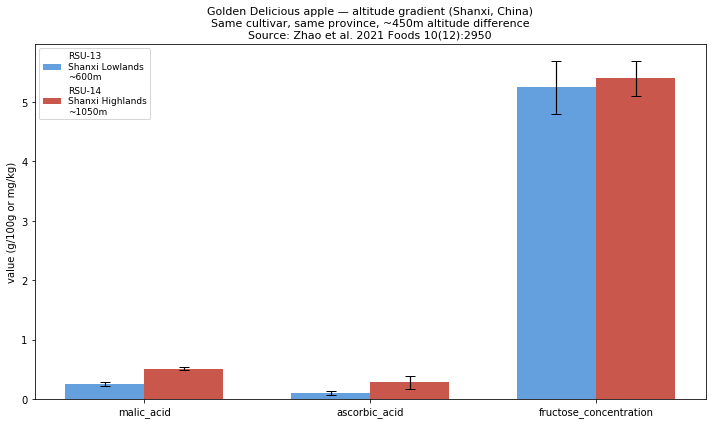

In [4]:
apple_rsus = EXPERIMENTS['apple']['rsus']
apple_dims = sorted(apple_df['dim'].unique())

rsu_colors_apple = {'RSU-13': '#4a90d9', 'RSU-14': '#c0392b'}
rsu_labels_apple = {}
for rsu_id in apple_rsus:
    e = env_map.get(rsu_id, {})
    alt = e.get('altitude_m', '?')
    rsu_labels_apple[rsu_id] = f"{rsu_id}\n{e.get('name','?')}\n~{alt}m"

x = np.arange(len(apple_dims))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

for k, rsu_id in enumerate(apple_rsus):
    sub = apple_df[apple_df['region_id'] == rsu_id]
    vals, los, his = [], [], []
    for dim in apple_dims:
        row = sub[sub['dim'] == dim]
        if len(row):
            vals.append(row.iloc[0]['value'])
            los.append(row.iloc[0]['value'] - row.iloc[0]['lo'])
            his.append(row.iloc[0]['hi'] - row.iloc[0]['value'])
        else:
            vals.append(np.nan)
            los.append(0)
            his.append(0)

    bars = ax.bar(x + k * width, vals, width,
                  label=rsu_labels_apple.get(rsu_id, rsu_id),
                  color=rsu_colors_apple.get(rsu_id, 'gray'), alpha=0.85)
    ax.errorbar(x + k * width, vals, yerr=[los, his],
                fmt='none', color='black', capsize=5, lw=1.2)

ax.set_xticks(x + width / 2)
ax.set_xticklabels([d.split('.')[-1] for d in apple_dims], fontsize=10)
ax.set_ylabel('value (g/100g or mg/kg)')
ax.set_title(
    'Golden Delicious apple — altitude gradient (Shanxi, China)\n'
    'Same cultivar, same province, ~450m altitude difference\n'
    'Source: Zhao et al. 2021 Foods 10(12):2950',
    fontsize=11
)
ax.legend(fontsize=9)
ax.axhline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.savefig('../data/metabolites/natural_exp_apple_altitude.png', dpi=150, bbox_inches='tight')
plt.show()

## Experiment 2: Olive Oil — Water Stress Gradient

**RSU-15** (Algerian Northern Highlands, Setif, ~1000m, 450mm rain) vs
**RSU-16** (Algerian Saharan Margin, Eloued, ~70m, 65mm rain)

Same cultivar: *Sigoise*. Both from the same national study.
Environmental contrast: 7× precipitation difference, 8°C temperature difference, very different soil.

**Expected mechanism:** Water stress triggers polyphenol biosynthesis as an oxidative stress response.
More water stress = more antioxidant polyphenols = higher bitterness, more bioactive oil.
Linoleic acid (polyunsaturated) tends to decrease under heat/drought; oleic acid more stable.

In [5]:
olive_df = df[df['experiment'] == 'olive'].copy()

print("Olive (Sigoise) — across water stress gradient:")
pivot_olive = olive_df.pivot(index='dim', columns='region_id', values='value')

rsu15_col = 'RSU-15' if 'RSU-15' in pivot_olive.columns else None
rsu16_col = 'RSU-16' if 'RSU-16' in pivot_olive.columns else None

if rsu15_col and rsu16_col:
    pivot_olive['delta'] = pivot_olive[rsu16_col] - pivot_olive[rsu15_col]
    pivot_olive['ratio_16_vs_15'] = (pivot_olive[rsu16_col] / pivot_olive[rsu15_col]).round(2)
    print(pivot_olive.round(3).to_string())
else:
    print(pivot_olive.round(3).to_string())
    print(f"\nMissing RSU columns — found: {list(pivot_olive.columns)}")
    print("Check that RSU-15 and RSU-16 JSON files are present and loaded.")

print("\nEnvironmental context:")
for rsu_id in EXPERIMENTS['olive']['rsus']:
    e = env_map.get(rsu_id, {})
    print(f"  {rsu_id} {e.get('name','?')}: altitude={e.get('altitude_m','?')}m, "
          f"temp={e.get('temp_mean','?')}°C, precip={e.get('precip_mean','?')}mm, "
          f"geology={e.get('geology','?')}, pH={e.get('soil_pH','?')}")

Olive (Sigoise) — across water stress gradient:
region_id                                 RSU-15  RSU-16  delta  ratio_16_vs_15
dim                                                                            
key_flavor_bioactives.polyphenol_content   617.5   891.5  274.0            1.44
key_flavor_bioactives.tocopherol_content    94.0   226.5  132.5            2.41
primary_metabolites.linoleic_acid           12.5    16.0    3.5            1.28
primary_metabolites.oleic_acid              67.0    60.5   -6.5            0.90

Environmental context:
  RSU-15 Algerian Northern Highlands: altitude=1000m, temp=14.0°C, precip=450mm, geology=limestone, pH=7.2
  RSU-16 Algerian Saharan Margin: altitude=70m, temp=22.0°C, precip=65mm, geology=aeolian_sand, pH=8.1


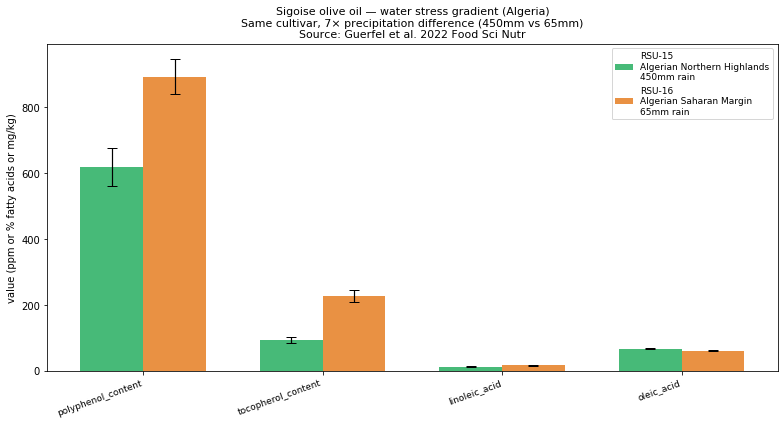

In [6]:
olive_rsus = EXPERIMENTS['olive']['rsus']
olive_dims = sorted(olive_df['dim'].unique())

rsu_colors_olive = {'RSU-15': '#27ae60', 'RSU-16': '#e67e22'}
rsu_labels_olive = {}
for rsu_id in olive_rsus:
    e = env_map.get(rsu_id, {})
    rsu_labels_olive[rsu_id] = (
        f"{rsu_id}\n{e.get('name','?')}\n"
        f"{e.get('precip_mean','?')}mm rain"
    )

x = np.arange(len(olive_dims))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

for k, rsu_id in enumerate(olive_rsus):
    sub = olive_df[olive_df['region_id'] == rsu_id]
    vals, los, his = [], [], []
    for dim in olive_dims:
        row = sub[sub['dim'] == dim]
        if len(row):
            vals.append(row.iloc[0]['value'])
            los.append(row.iloc[0]['value'] - row.iloc[0]['lo'])
            his.append(row.iloc[0]['hi'] - row.iloc[0]['value'])
        else:
            vals.append(np.nan)
            los.append(0)
            his.append(0)

    ax.bar(x + k * width, vals, width,
           label=rsu_labels_olive.get(rsu_id, rsu_id),
           color=rsu_colors_olive.get(rsu_id, 'gray'), alpha=0.85)
    ax.errorbar(x + k * width, vals, yerr=[los, his],
                fmt='none', color='black', capsize=5, lw=1.2)

ax.set_xticks(x + width / 2)
ax.set_xticklabels([d.split('.')[-1] for d in olive_dims], fontsize=9, rotation=20, ha='right')
ax.set_ylabel('value (ppm or % fatty acids or mg/kg)')
ax.set_title(
    'Sigoise olive oil — water stress gradient (Algeria)\n'
    'Same cultivar, 7× precipitation difference (450mm vs 65mm)\n'
    'Source: Guerfel et al. 2022 Food Sci Nutr',
    fontsize=11
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../data/metabolites/natural_exp_olive_water_stress.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary: What these experiments show

These are the first genuinely controlled terroir comparisons in TerraMetabolica.
No genetic confound. No imputation. Same cultivar, measured values.

In [7]:
summary = []

for exp_name, exp in EXPERIMENTS.items():
    rsu_a, rsu_b = exp['rsus'][0], exp['rsus'][1]
    food = exp['food']
    sub = df[df['experiment'] == exp_name]
    shared_dims = sub['dim'].unique()

    for dim in shared_dims:
        row_a = sub[(sub['region_id'] == rsu_a) & (sub['dim'] == dim)]
        row_b = sub[(sub['region_id'] == rsu_b) & (sub['dim'] == dim)]
        if len(row_a) and len(row_b):
            va = row_a.iloc[0]['value']
            vb = row_b.iloc[0]['value']
            if va > 0:
                ratio = vb / va
                summary.append({
                    'experiment': exp_name,
                    'cultivar': exp['cultivar'],
                    'metabolite': dim.split('.')[-1],
                    f'{rsu_a}': round(va, 4),
                    f'{rsu_b}': round(vb, 4),
                    'ratio (B/A)': round(ratio, 2),
                    'contrast': exp['contrast'],
                    'source': exp['source'],
                })

summary_df = pd.DataFrame(summary)
if len(summary_df):
    print("Clean terroir signals — same cultivar, different environment:")
    print(summary_df.sort_values('ratio (B/A)', ascending=False).to_string(index=False))
else:
    print("No cross-RSU pairs found. Check that RSU-13 through RSU-16 are loaded.")

Clean terroir signals — same cultivar, different environment:
experiment         cultivar             metabolite  RSU-13  RSU-14  ratio (B/A)     contrast                                       source  RSU-15  RSU-16
     apple Golden Delicious          ascorbic_acid    0.10   0.280         2.80     altitude           Zhao et al. 2021 Foods 10(12):2950     NaN     NaN
     olive          Sigoise     tocopherol_content     NaN     NaN         2.41 water stress Guerfel et al. 2022 Food Sci Nutr PMC9179137    94.0   226.5
     apple Golden Delicious             malic_acid    0.25   0.505         2.02     altitude           Zhao et al. 2021 Foods 10(12):2950     NaN     NaN
     olive          Sigoise     polyphenol_content     NaN     NaN         1.44 water stress Guerfel et al. 2022 Food Sci Nutr PMC9179137   617.5   891.5
     olive          Sigoise          linoleic_acid     NaN     NaN         1.28 water stress Guerfel et al. 2022 Food Sci Nutr PMC9179137    12.5    16.0
     apple Gol